# Session 9.3: Evaluation Metrics & Model Debugging

<table cellpadding="10" cellspacing="0" border="0" width="100%"><tr>
<td bgcolor="#ED1C24" width="4"></td>
<td bgcolor="#fce4ec" font-weight="bold">
<font color="#c62828"><b>Program:</b></font> Vishlesan i-Hub IIT Patna x Masai School -- AIM (AI & Machine Learning)<br>
<font color="#c62828"><b>Session ID:</b></font> 9.3 | <b>Week:</b> 9<br>
<font color="#c62828"><b>Prerequisites:</b></font> Session 9.2 (Logistic Regression & Classification)<br>
<font color="#c62828"><b>Estimated Completion Time:</b></font> 90-120 minutes (self-paced)
</td>
</tr></table>

---

Vishlesan i-Hub IIT Patna x Masai School

## Learning Objectives

By the end of this notebook, you will be able to:

1. **Construct and interpret** multi-class confusion matrices with Plotly heatmaps
2. **Compute and compare** micro, macro, and weighted averaging for precision, recall, and F1
3. **Build and interpret** ROC curves and compute AUC for threshold-independent evaluation
4. **Explain** the bias-variance tradeoff and connect it to overfitting/underfitting
5. **Diagnose** model problems using learning curves and the 3-step diagnostic rule
6. **Apply** a systematic 5-step error analysis workflow to debug models
7. **Select** the appropriate metric for a given business context using cost-sensitive thinking

## Prerequisites

Before starting this notebook, you should be comfortable with:

- Building logistic regression classifiers with sklearn (Session 9.2)
- Interpreting a 2x2 confusion matrix (TP, FP, FN, TN)
- Computing precision, recall, and F1-score for binary classification
- Using `predict_proba()` to get probability scores
- Understanding that accuracy can be misleading on imbalanced data

<details>
<summary><font color="#2e7d32"><b>Quick Self-Check: Am I Ready?</b></font></summary>

1. What is precision? -> TP / (TP + FP) -- purity of positive predictions
2. For cancer screening, prioritize precision or recall? -> Recall (cannot miss cancer)
3. Default logistic regression threshold? -> 0.5 (a choice, not a law)

If all three were instant, you are ready. If not, review Session 9.2 materials first.

</details>

## Setup & Imports

In [1]:
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split, learning_curve
from sklearn.linear_model import LogisticRegression, LinearRegression
from sklearn.preprocessing import StandardScaler, PolynomialFeatures
from sklearn.pipeline import Pipeline
from sklearn.metrics import (confusion_matrix, classification_report,
                              roc_curve, roc_auc_score, accuracy_score,
                              precision_score, recall_score, f1_score,
                              r2_score)
import plotly.graph_objects as go
from plotly.subplots import make_subplots
import plotly.io as pio
pio.renderers.default = "colab"

import warnings
warnings.filterwarnings('ignore')

print("All libraries loaded successfully!")
print(f"NumPy: {np.__version__}")
print(f"Pandas: {pd.__version__}")

All libraries loaded successfully!
NumPy: 2.4.6
Pandas: 3.0.3


### Callout Box Helper

Run this cell to enable styled callout boxes used throughout the notebook.

In [2]:
from IPython.display import HTML, display

_BOX_STYLES = {
    "definition": ("#448aff", "#e3f2fd", "#1565c0"),
    "tip":        ("#00c853", "#e8f5e9", "#2e7d32"),
    "warning":    ("#ff9100", "#fff3e0", "#e65100"),
    "danger":     ("#ff1744", "#fce4ec", "#c62828"),
    "math":       ("#7c4dff", "#ede7f6", "#4527a0"),
    "output":     ("#00b8d4", "#e0f7fa", "#006064"),
    "industry":   ("#009688", "#e0f2f1", "#004d40"),
}

def box(kind, title, content):
    """Display styled callout box.
    kind: definition|tip|warning|danger|math|output|industry
    """
    border, bg, title_clr = _BOX_STYLES[kind]
    display(HTML(f"""
    <div style="margin:12px 0; color: gray; padding:12px 16px; border-left:4px solid {border};
                background-color:{bg}; border-radius:4px;">
    <strong style="color:{title_clr};">{title}</strong><br>{content}
    </div>"""))

box("tip", "Setup Complete", "All callout boxes are ready. Let's begin!")

---

## Business Context: The $32 Billion Problem

In [3]:
box("industry", "Credit Card Fraud: The $32 Billion Problem",
    "Credit card fraud costs the global financial industry over $32 billion annually. "
    "The fundamental challenge is extreme class imbalance: legitimate transactions vastly "
    "outnumber fraudulent ones. A naive model predicting 'not fraud' for every transaction "
    "achieves high accuracy -- and catches <b>zero fraud</b>. Today you will learn to see "
    "through this accuracy trap and build a complete diagnostic toolkit for model evaluation.")

In this notebook, we work with a synthetic credit card fraud dataset of **10,000 transactions**. Our goal is not just to build a model, but to **evaluate it properly** and **diagnose what is wrong** when it underperforms.

The key question: **"How do I know if my model is actually good, and how do I fix it when it is not?"**

## Part 1: Dataset -- Credit Card Transactions

We generate a realistic synthetic dataset with 10,000 transactions. Fraudulent transactions have different patterns: higher amounts, farther from home, more often at night, and more often online.

In [4]:
# ============================================================
# DATASET: Credit Card Fraud Detection (10,000 transactions)
# ============================================================
np.random.seed(42)

n = 10000
fraud_rate = 0.05
is_fraud = np.random.choice([0, 1], size=n, p=[1 - fraud_rate, fraud_rate])

transaction_amount = np.where(is_fraud,
    np.random.exponential(200, n) + 80,    # Fraud: moderate amounts (overlap with legit)
    np.random.exponential(80, n) + 10)     # Legit: smaller amounts

distance_from_home = np.where(is_fraud,
    np.random.exponential(40, n) + 15,     # Fraud: somewhat far (overlap with legit)
    np.random.exponential(15, n) + 1)      # Legit: close to home

time_of_day = np.where(is_fraud,
    np.random.normal(2, 4, n) % 24,       # Fraud: wider spread
    np.random.normal(14, 5, n) % 24)      # Legit: wider spread

is_online = np.where(is_fraud,
    np.random.choice([0, 1], n, p=[0.3, 0.7]),  # 70% of fraud is online
    np.random.choice([0, 1], n, p=[0.5, 0.5]))  # 50% of legit is online

merchant_risk_score = np.where(is_fraud,
    np.clip(np.random.normal(0.55, 0.2, n), 0, 1),  # Fraud: moderate risk (overlap)
    np.clip(np.random.normal(0.3, 0.2, n), 0, 1))   # Legit: low risk

customer_age = np.where(is_fraud,
    np.clip(np.random.normal(38, 13, n), 18, 85),   # Fraud: close to legit age
    np.clip(np.random.normal(42, 12, n), 18, 85))   # Legit: slightly older

transaction_frequency = np.where(is_fraud,
    np.random.poisson(5, n),              # Fraud: moderate frequency (overlap)
    np.random.poisson(8, n))              # Legit: regular customers

df = pd.DataFrame({
    'transaction_amount': np.round(transaction_amount, 2),
    'distance_from_home': np.round(distance_from_home, 2),
    'time_of_day': np.round(time_of_day, 2),
    'is_online': is_online,
    'merchant_risk_score': np.round(merchant_risk_score, 4),
    'customer_age': np.round(customer_age, 1),
    'transaction_frequency': transaction_frequency,
    'is_fraud': is_fraud
})

n_fraud = is_fraud.sum()
n_legit = n - n_fraud

print("=" * 60)
print("CREDIT CARD FRAUD DATASET")
print("=" * 60)
print(f"Total transactions: {n:,}")
print(f"  Legitimate: {n_legit:,} ({n_legit/n*100:.1f}%)")
print(f"  Fraudulent: {n_fraud:,} ({n_fraud/n*100:.1f}%)")
print(f"\nFeatures: {list(df.columns[:-1])}")
df.head()

CREDIT CARD FRAUD DATASET
Total transactions: 10,000
  Legitimate: 9,526 (95.3%)
  Fraudulent: 474 (4.7%)

Features: ['transaction_amount', 'distance_from_home', 'time_of_day', 'is_online', 'merchant_risk_score', 'customer_age', 'transaction_frequency']


,transaction_amount,distance_from_home,time_of_day,is_online,merchant_risk_score,customer_age,transaction_frequency,is_fraud
0,114.75,6.33,19.73,1,0.0812,54.8,11,0
1,160.97,39.60,6.83,0,0.8006,23.3,5,1
2,44.05,3.03,9.50,1,0.2949,45.7,12,0
3,97.08,3.99,7.80,1,0.1822,53.5,13,0
4,62.64,4.42,15.15,1,0.6722,52.0,5,0


### Training the Baseline Model

We train a logistic regression classifier to detect fraud. This model will be the subject of our evaluation and debugging throughout this notebook.

In [5]:


features = ['transaction_amount', 'distance_from_home', 'time_of_day',
            'is_online', 'merchant_risk_score', 'customer_age',
            'transaction_frequency']

X = df[features]
y = df['is_fraud']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y)

pipeline = Pipeline([
    ('scaler', StandardScaler()),
    ('model', LogisticRegression(random_state=42, max_iter=1000))
])
pipeline.fit(X_train, y_train)

y_pred = pipeline.predict(X_test)
y_proba = pipeline.predict_proba(X_test)[:, 1]

print("=" * 50)
print("BASELINE MODEL TRAINED")
print("=" * 50)
print(f"Training samples: {len(X_train):,}")
print(f"Test samples:     {len(X_test):,}")
print(f"Test accuracy:    {accuracy_score(y_test, y_pred):.4f}")

BASELINE MODEL TRAINED
Training samples: 8,000
Test samples:     2,000
Test accuracy:    0.9765


---

## Part 2: The Accuracy Trap -- Multiple Wrong Approaches

Recall from Session 9.2 that accuracy can be misleading on imbalanced data. Let us see this dramatically with three different strategies.

In [6]:
box("danger", "The Accuracy Trap",
    "On imbalanced data, accuracy rewards the model for ignoring the minority class. "
    "A model that predicts 'not fraud' for every single transaction achieves ~95% accuracy -- "
    "and catches <b>zero fraud</b>. Never rely on accuracy alone.")

In [7]:
# ============================================================
# THREE EVALUATION STRATEGIES
# ============================================================
y_always_legit = np.zeros_like(y_test)
y_always_fraud = np.ones_like(y_test)

strategies = [
    ("Always 'Not Fraud'", y_always_legit),
    ("Always 'Fraud'", y_always_fraud),
    ("Logistic Regression", y_pred)
]

print("=" * 65)
print("THREE EVALUATION STRATEGIES -- Which is best?")
print("=" * 65)

for name, preds in strategies:
    acc = accuracy_score(y_test, preds)
    rec = recall_score(y_test, preds, zero_division=0)
    prec = precision_score(y_test, preds, zero_division=0)
    print(f"\n{name}:")
    print(f"   Accuracy:  {acc:.4f}")
    print(f"   Precision: {prec:.4f}")
    print(f"   Recall:    {rec:.4f}")

print("\n" + "=" * 65)
print("LESSON: Accuracy alone is MEANINGLESS on imbalanced data!")

THREE EVALUATION STRATEGIES -- Which is best?

Always 'Not Fraud':
   Accuracy:  0.9525
   Precision: 0.0000
   Recall:    0.0000

Always 'Fraud':
   Accuracy:  0.0475
   Precision: 0.0475
   Recall:    1.0000

Logistic Regression:
   Accuracy:  0.9765
   Precision: 0.8750
   Recall:    0.5895

LESSON: Accuracy alone is MEANINGLESS on imbalanced data!


---

## Part 3: Multi-Class Confusion Matrix Deep-Dive

In Session 9.2, you worked with a 2x2 confusion matrix. But many real problems have more than 2 classes. What happens then?

> Think of it this way: in 9.2, your confusion matrix was like sorting coins -- heads or tails. Real classification is like **sorting mail into multiple mailboxes**. The confusion matrix becomes an NxN grid showing which mailboxes get each other's mail.

In [8]:
box("definition", "Multi-Class Confusion Matrix",
    "An NxN matrix where row i and column j contains the count of samples "
    "from <b>actual class i</b> that were <b>predicted as class j</b>. "
    "Rows = actual (truth). Columns = predicted (model output). "
    "Diagonal cells = correct predictions. Off-diagonal = errors.")

### Creating a 3-Class Fraud Problem

We split fraud into two severity levels:
- **Class 0:** No Fraud (legitimate transaction)
- **Class 1:** Small Fraud (amount < $300)

- **Class 2:** Large Fraud (amount >= $300)

In [9]:
df_3class = df.copy()
df_3class['fraud_type'] = 0
fraud_mask = df_3class['is_fraud'] == 1
df_3class.loc[fraud_mask & (df_3class['transaction_amount'] < 300), 'fraud_type'] = 1
df_3class.loc[fraud_mask & (df_3class['transaction_amount'] >= 300), 'fraud_type'] = 2

class_names = ['No Fraud', 'Small Fraud', 'Large Fraud']

print("3-Class Distribution:")
for ci, cn in enumerate(class_names):
    count = (df_3class['fraud_type'] == ci).sum()
    print(f"  {cn}: {count:,} ({count/n*100:.1f}%)")

X_3 = df_3class[features]
y_3 = df_3class['fraud_type']

X_train_3, X_test_3, y_train_3, y_test_3 = train_test_split(
    X_3, y_3, test_size=0.2, random_state=42, stratify=y_3)

pipeline_3 = Pipeline([
    ('scaler', StandardScaler()),
    ('model', LogisticRegression(random_state=42, max_iter=1000))
])
pipeline_3.fit(X_train_3, y_train_3)
y_pred_3 = pipeline_3.predict(X_test_3)

3-Class Distribution:
  No Fraud: 9,526 (95.3%)
  Small Fraud: 304 (3.0%)
  Large Fraud: 170 (1.7%)


### Step-by-Step: Manual Confusion Matrix Before sklearn

Before using the library, let us compute the confusion matrix by hand.

In [10]:
manual_cm = np.zeros((3, 3), dtype=int)
for actual, predicted in zip(y_test_3, y_pred_3):
    manual_cm[actual][predicted] += 1

print("MANUAL Confusion Matrix:")
print("=" * 55)
header = f"{'':>15}"
for name in class_names:
    header += f"{name:>15}"
print(header + "  <- Predicted")
print("-" * 55)
for i, name in enumerate(class_names):
    row = f"{name:>15}"
    for j in range(3):
        row += f"{manual_cm[i][j]:>15}"
    print(row)
print("^ Actual")

sklearn_cm = confusion_matrix(y_test_3, y_pred_3)
print(f"\nsklearn matches manual: {np.array_equal(manual_cm, sklearn_cm)}")

MANUAL Confusion Matrix:
                      No Fraud    Small Fraud    Large Fraud  <- Predicted
-------------------------------------------------------
       No Fraud           1897              3              5
    Small Fraud             33             28              0
    Large Fraud              5              3             26
^ Actual

sklearn matches manual: True


In [11]:
box("output", "Reading the Multi-Class Confusion Matrix",
    "Each cell [row i, col j] means: '<b>actual</b> class i was <b>predicted</b> as class j.' "
    "The diagonal shows correct predictions. Off-diagonal shows WHERE the model confuses classes.")

### Normalized Confusion Matrix & Interactive Heatmap

Raw counts can be misleading when class sizes differ. Normalized version shows percentages per actual class.

In [12]:
cm_raw = confusion_matrix(y_test_3, y_pred_3)
cm_norm = confusion_matrix(y_test_3, y_pred_3, normalize='true')

annotations = []
for i in range(3):
    row = []
    for j in range(3):
        row.append(f"{cm_raw[i][j]}<br>({cm_norm[i][j]*100:.1f}%)")
    annotations.append(row)

fig = go.Figure(data=go.Heatmap(
    z=cm_norm, x=class_names, y=class_names,
    text=annotations, texttemplate="%{text}", textfont=dict(size=14),
    colorscale=[[0, '#FFFFFF'], [0.5, '#FFB3B3'], [1, '#ED1C24']],
    hovertemplate="Actual: %{y}<br>Predicted: %{x}<br>Count: %{customdata}<br>Pct: %{z:.1%}<extra></extra>",
    customdata=cm_raw, showscale=True, colorbar=dict(title="Proportion")
))

fig.update_layout(
    title="Multi-Class Confusion Matrix: Fraud Detection",
    xaxis_title="Predicted Class", yaxis_title="Actual Class",
    width=700, height=550, plot_bgcolor="white",
    yaxis=dict(autorange="reversed")
)
fig.show()

In [13]:
box("tip", "When to Normalize",
    "Normalize when class sizes differ significantly. With 9,500 'No Fraud' and 50 'Large Fraud' "
    "samples, raw counts are misleading. Normalized view shows the <b>percentage of each actual "
    "class</b> that was classified correctly or incorrectly.")

---

## Part 4: Advanced Precision/Recall/F1 -- Averaging Strategies

In Session 9.2, precision and recall were single numbers (binary). With 3+ classes, each class has its OWN precision, recall, and F1. How do we get one overall number?

> **Analogy:** Three teachers -- one teaches 100 students, one teaches 30, one teaches 5. Computing the "average teaching score": do you weight all three equally (**macro**) or by how many students each teaches (**weighted**)? If the teacher with 5 students is terrible, macro drags the average down hard. Weighted barely notices.

In [14]:
box("definition", "Macro vs Weighted vs Micro Averaging",
    "<b>Macro average:</b> Compute metric for each class, take unweighted mean. Treats every class equally regardless of size. <i>Use when: minority classes matter (fraud, rare diseases).</i><br><br>"
    "<b>Weighted average:</b> Mean weighted by support (sample count). Bigger classes dominate the average. <i>Use when: you want overall system performance reflecting real data distribution.</i><br><br>"
    "<b>Micro average:</b> Pool all TP/FP/FN globally, compute one metric. Equals accuracy for multi-class. <i>Use when: classes are balanced (all three give similar results anyway).</i><br><br>"
    "<b>Rule of thumb:</b> Imbalanced data + minority matters? <b>Macro</b>. Want overall picture? <b>Weighted</b>. Balanced data? Any works.")

In [15]:
print("=" * 60)
print("THREE AVERAGING METHODS -- Same model, different stories!")
print("=" * 60)

for avg in ['macro', 'weighted', 'micro']:
    p = precision_score(y_test_3, y_pred_3, average=avg, zero_division=0)
    r = recall_score(y_test_3, y_pred_3, average=avg, zero_division=0)
    f = f1_score(y_test_3, y_pred_3, average=avg, zero_division=0)
    print(f"\n{avg.upper()} Average:")
    print(f"   Precision: {p:.4f}")
    print(f"   Recall:    {r:.4f}")
    print(f"   F1-Score:  {f:.4f}")

THREE AVERAGING METHODS -- Same model, different stories!

MACRO Average:
   Precision: 0.8809
   Recall:    0.7398
   F1-Score:  0.7925

WEIGHTED Average:
   Precision: 0.9732
   Recall:    0.9755
   F1-Score:  0.9727

MICRO Average:
   Precision: 0.9755
   Recall:    0.9755
   F1-Score:  0.9755


In [16]:
box("warning", "Macro Average Amplifies Minority Class",
    "Macro average gives <b>equal weight</b> to every class. If the fraud class has "
    "terrible recall, macro drops significantly -- even though the model works fine on "
    "legitimate transactions. This is often DESIRABLE: it forces you to notice poor "
    "minority class performance. Weighted average can <b>hide</b> the problem.")

### classification_report Deep Dive

In [17]:
report = classification_report(y_test_3, y_pred_3,
                                target_names=class_names, zero_division=0)
print("CLASSIFICATION REPORT:")
print("=" * 60)
print(report)

CLASSIFICATION REPORT:
              precision    recall  f1-score   support

    No Fraud       0.98      1.00      0.99      1905
 Small Fraud       0.82      0.46      0.59        61
 Large Fraud       0.84      0.76      0.80        34

    accuracy                           0.98      2000
   macro avg       0.88      0.74      0.79      2000
weighted avg       0.97      0.98      0.97      2000



In [18]:
box("output", "Reading classification_report",
    "<b>Each row</b> = one class. <b>support</b> = actual sample count.<br>"
    "<b>precision</b> = of predictions for this class, how many correct?<br>"
    "<b>recall</b> = of actual samples of this class, how many found?<br>"
    "<b>f1-score</b> = harmonic mean of precision and recall.<br>"
    "<b>macro avg</b> = unweighted mean. <b>weighted avg</b> = weighted by support.")

### Visualization: Per-Class Metrics

In [19]:
report_dict = classification_report(y_test_3, y_pred_3,
    target_names=class_names, output_dict=True, zero_division=0)

metrics = ['precision', 'recall', 'f1-score']
colors = {'precision': '#ED1C24', 'recall': '#3498DB', 'f1-score': '#2ECC71'}

fig = go.Figure()
for metric in metrics:
    values = [report_dict[cn][metric] for cn in class_names]
    fig.add_trace(go.Bar(name=metric.capitalize(), x=class_names, y=values,
        marker_color=colors[metric],
        hovertemplate=f"Class: %{{x}}<br>{metric.capitalize()}: %{{y:.4f}}<extra></extra>"))

macro_f1 = report_dict['macro avg']['f1-score']
weighted_f1 = report_dict['weighted avg']['f1-score']
fig.add_hline(y=macro_f1, line_dash="dash", line_color="#FF9100",
    annotation_text=f"Macro F1: {macro_f1:.3f}", annotation_position="top right")
fig.add_hline(y=weighted_f1, line_dash="dot", line_color="#7c4dff",
    annotation_text=f"Weighted F1: {weighted_f1:.3f}", annotation_position="bottom right")

fig.update_layout(title="Per-Class Metrics with Macro & Weighted F1",
    xaxis_title="Class", yaxis_title="Score",
    barmode='group', width=900, height=500,
    plot_bgcolor="white", yaxis=dict(range=[0, 1.05]))
fig.show()

---

## Part 5: ROC Curve & AUC -- Evaluating Across ALL Thresholds

In Session 9.2, you tried 3 thresholds (0.3, 0.5, 0.7). The ROC curve does this across **every possible threshold** simultaneously.

> **Analogy:** In 9.2, you tasted wine at 3 temperatures. The ROC curve tastes it at **every** temperature. AUC summarizes "how good is this wine overall" in a single number.

In [20]:
box("definition", "ROC Curve",
    "The <b>Receiver Operating Characteristic</b> curve plots True Positive Rate (TPR) vs "
    "False Positive Rate (FPR) at every possible classification threshold.<br>"
    "<b>TPR</b> = TP/(TP+FN) = Recall = 'Of all fraud, how many caught?'<br>"
    "<b>FPR</b> = FP/(FP+TN) = 'Of all legit, how many wrongly flagged?'<br>"
    "The upper-left corner (TPR=1, FPR=0) is ideal.")

In [21]:
box("math", "TPR and FPR Formulas",
    "<code>TPR = TP / (TP + FN)</code> -- also called Recall or Sensitivity<br>"
    "<code>FPR = FP / (FP + TN)</code> -- also called Fall-out or False Alarm Rate<br>"
    "As threshold decreases: both TPR and FPR increase.")

### Step-by-Step: Manual ROC Computation at 5 Thresholds

In [22]:
thresholds_manual = [0.1, 0.3, 0.5, 0.7, 0.9]

print("MANUAL ROC Point Computation:")
print("=" * 70)
print(f"{'Threshold':>10} {'TP':>5} {'FP':>6} {'FN':>5} {'TN':>6} {'TPR':>8} {'FPR':>8}")
print("-" * 70)

tpr_manual = []
fpr_manual = []

for thresh in thresholds_manual:
    y_pred_t = (y_proba >= thresh).astype(int)
    tp = ((y_pred_t == 1) & (y_test == 1)).sum()
    fp = ((y_pred_t == 1) & (y_test == 0)).sum()
    fn = ((y_pred_t == 0) & (y_test == 1)).sum()
    tn = ((y_pred_t == 0) & (y_test == 0)).sum()
    tpr_val = tp / (tp + fn) if (tp + fn) > 0 else 0
    fpr_val = fp / (fp + tn) if (fp + tn) > 0 else 0
    tpr_manual.append(tpr_val)
    fpr_manual.append(fpr_val)
    print(f"{thresh:>10.1f} {tp:>5} {fp:>6} {fn:>5} {tn:>6} {tpr_val:>8.4f} {fpr_val:>8.4f}")

print("\nAs threshold DECREASES: TPR increases (more fraud caught)")
print("BUT FPR also increases (more false alarms).")

MANUAL ROC Point Computation:
 Threshold    TP     FP    FN     TN      TPR      FPR
----------------------------------------------------------------------
       0.1    83     85    12   1820   0.8737   0.0446
       0.3    69     20    26   1885   0.7263   0.0105
       0.5    56      8    39   1897   0.5895   0.0042
       0.7    48      4    47   1901   0.5053   0.0021
       0.9    31      1    64   1904   0.3263   0.0005

As threshold DECREASES: TPR increases (more fraud caught)
BUT FPR also increases (more false alarms).


### sklearn ROC Curve & AUC

In [24]:
fpr_sk, tpr_sk, _ = roc_curve(y_test, y_proba)
auc_score = roc_auc_score(y_test, y_proba)

sk_roc = pd.DataFrame({
    'Threshold': np.round(_, 3),
    'FPR': np.round(fpr_sk, 4),
    'TPR': np.round(tpr_sk, 4)
})

print(f"AUC Score: {auc_score:.4f}")
print(f"\nInterpretation: {auc_score*100:.1f}% chance the model")
print("ranks a random fraud higher than a random legit transaction.")
sk_roc

AUC Score: 0.9730

Interpretation: 97.3% chance the model
ranks a random fraud higher than a random legit transaction.


,Threshold,FPR,TPR
0,inf,0.0000,0.0000
1,1.000,0.0000,0.0105
2,0.909,0.0000,0.3158
3,0.905,0.0005,0.3158
4,0.818,0.0005,0.4316
...,...,...,...
77,0.009,0.2499,0.9789
78,0.009,0.2499,0.9895
79,0.000,0.8052,0.9895
80,0.000,0.8052,1.0000


In [28]:
## Plotting the ROC Curve
fig = go.Figure()
fig.add_trace(go.Scatter(x=sk_roc['FPR'], y=sk_roc['TPR'], mode='lines', name='ROC Curve'))
fig.update_layout(title='ROC Curve', xaxis_title='False Positive Rate', yaxis_title='True Positive Rate')
## Visualize AOC Score
fig.add_trace(go.Scatter(x=[0, 1], y=[0, 1], mode='lines', name='Random Classifier', line=dict(dash='dash', color='gray')))
fig.show()

In [29]:
box("definition", "AUC (Area Under the Curve)",
    "Summarizes the entire ROC curve in one number (0 to 1).<br>"
    "<b>0.5</b> = random guessing<br><b>0.7-0.8</b> = fair<br>"
    "<b>0.8-0.9</b> = good<br><b>0.9+</b> = excellent<br><b>1.0</b> = perfect<br><br>"
    "Intuitive meaning: probability that model ranks a random positive higher than a random negative.")

### Interactive ROC-AUC Explorer (Two Sliders)

This visualization has **two independent controls**:

1. **Model Skill (Separation)** — how well the model distinguishes positive from negative classes. Higher separation = better model = ROC curve moves toward upper-left.
2. **Decision Threshold** — where you draw the line between "predict positive" and "predict negative." Moving the threshold changes TPR and FPR but NOT the AUC.

Watch how the **colored regions** change:
- <font color="#2ECC71"><b>Green (TN)</b></font>: Correctly identified negatives
- <font color="#E74C3C"><b>Red (FP)</b></font>: False alarms (negatives predicted as positive)
- <font color="#FF9100"><b>Orange (FN)</b></font>: Missed positives (positives predicted as negative)
- <font color="#3498DB"><b>Blue (TP)</b></font>: Correctly identified positives

**Key insight:** AUC depends ONLY on separation (model quality). The threshold slider moves the operating point ALONG the ROC curve without changing its shape.

In [31]:
# ============================================================
# INTERACTIVE ROC-AUC EXPLORER (Two Sliders)
# Slider 1: Model Skill (class separation)
# Slider 2: Decision Threshold position
# ============================================================
from scipy import stats as sp_stats

x_vals = np.linspace(-5, 9, 400)
seps = [0.0, 0.5, 1.0, 1.5, 2.0, 2.5, 3.0, 3.5, 4.0]
thresh_pos = [-1.0, -0.5, 0.0, 0.25, 0.5, 0.75, 1.0, 1.5, 2.0, 2.5, 3.0, 3.5, 4.0]

fig_roc = make_subplots(rows=2, cols=1, row_heights=[0.45, 0.55],
    vertical_spacing=0.12,
    subplot_titles=["<b>Class Distributions with Decision Boundary</b>",
                     "<b>ROC Curve</b>"])

all_frames = []
sep_steps = []
th_steps = []

# Default: sep=1.5, threshold=0.75
default_sep_idx = 3  # sep=1.5
default_th_idx = 5   # thresh=0.75

for si, sep in enumerate(seps):
    for ti, th in enumerate(thresh_pos):
        traces = []
        neg_pdf = sp_stats.norm.pdf(x_vals, 0, 1)
        pos_pdf = sp_stats.norm.pdf(x_vals, sep, 1)
        tpr = 1 - sp_stats.norm.cdf(th, sep, 1)
        fpr = 1 - sp_stats.norm.cdf(th, 0, 1)
        auc = sp_stats.norm.cdf(sep / np.sqrt(2))
        peak = max(neg_pdf.max(), pos_pdf.max())
        below = x_vals <= th
        above = x_vals >= th

        bx, ax = x_vals[below], x_vals[above]
        # TN (green), FP (red), FN (orange), TP (blue)
        traces.append(go.Scatter(x=np.concatenate([bx,bx[::-1]]),
            y=np.concatenate([sp_stats.norm.pdf(bx,0,1),np.zeros(below.sum())]),
            fill="toself",fillcolor="rgba(46,204,113,0.35)",line=dict(width=0),showlegend=False,hoverinfo="skip"))
        traces.append(go.Scatter(x=np.concatenate([ax,ax[::-1]]),
            y=np.concatenate([sp_stats.norm.pdf(ax,0,1),np.zeros(above.sum())]),
            fill="toself",fillcolor="rgba(231,76,60,0.4)",line=dict(width=0),showlegend=False,hoverinfo="skip"))
        traces.append(go.Scatter(x=np.concatenate([bx,bx[::-1]]),
            y=np.concatenate([sp_stats.norm.pdf(bx,sep,1),np.zeros(below.sum())]),
            fill="toself",fillcolor="rgba(255,145,0,0.35)",line=dict(width=0),showlegend=False,hoverinfo="skip"))
        traces.append(go.Scatter(x=np.concatenate([ax,ax[::-1]]),
            y=np.concatenate([sp_stats.norm.pdf(ax,sep,1),np.zeros(above.sum())]),
            fill="toself",fillcolor="rgba(52,152,219,0.4)",line=dict(width=0),showlegend=False,hoverinfo="skip"))
        # Distribution curves
        traces.append(go.Scatter(x=x_vals,y=neg_pdf,mode="lines",line=dict(color="#E74C3C",width=3),
            showlegend=(si==0 and ti==0),name="Negative Class" if (si==0 and ti==0) else None,hoverinfo="skip"))
        traces.append(go.Scatter(x=x_vals,y=pos_pdf,mode="lines",line=dict(color="#2ECC71",width=3),
            showlegend=(si==0 and ti==0),name="Positive Class" if (si==0 and ti==0) else None,hoverinfo="skip"))
        # Threshold line + label
        traces.append(go.Scatter(x=[th,th],y=[0,peak*1.1],mode="lines",
            line=dict(color="white",width=2.5,dash="dash"),showlegend=False,hoverinfo="skip"))
        traces.append(go.Scatter(x=[th+0.15],y=[peak*1.08],mode="text",
            text=[f"<b>Threshold={th:.2f}</b><br>TPR={tpr:.1%} | FPR={fpr:.1%} | AUC={auc:.3f}"],
            textfont=dict(color="white",size=10),textposition="middle right",showlegend=False,hoverinfo="skip"))
        # ROC curve
        rt = np.linspace(-4, sep+4, 200)
        rf = [1-sp_stats.norm.cdf(t,0,1) for t in rt]
        rr = [1-sp_stats.norm.cdf(t,sep,1) for t in rt]
        traces.append(go.Scatter(x=rf,y=rr,fill="tozeroy",fillcolor="rgba(52,152,219,0.15)",
            line=dict(color="#3498DB",width=3),showlegend=False,
            hovertemplate="FPR: %{x:.3f}<br>TPR: %{y:.3f}<extra></extra>"))
        traces.append(go.Scatter(x=[0,1],y=[0,1],mode="lines",
            line=dict(color="rgba(255,255,255,0.3)",dash="dash",width=1.5),showlegend=False,hoverinfo="skip"))
        # Operating point
        traces.append(go.Scatter(x=[fpr],y=[tpr],mode="markers",
            marker=dict(color="#ED1C24",size=14,line=dict(color="white",width=2)),showlegend=False,
            hovertemplate=f"TPR: {tpr:.3f}<br>FPR: {fpr:.3f}<extra></extra>"))
        traces.append(go.Scatter(x=[0.65],y=[0.18],mode="text",
            text=[f"<b>AUC = {auc:.3f}</b>"],textfont=dict(color="#3498DB",size=18),
            showlegend=False,hoverinfo="skip"))

        fname = f"s{si}_t{ti}"
        all_frames.append(go.Frame(data=traces, name=fname))

# Separation slider steps
for si, sep in enumerate(seps):
    fname = f"s{si}_t{default_th_idx}"
    sep_steps.append(dict(args=[[fname],dict(mode="immediate",frame=dict(duration=0,redraw=True))],
        label=f"{sep:.1f}",method="animate"))

# Threshold slider steps
for ti, th in enumerate(thresh_pos):
    fname = f"s{default_sep_idx}_t{ti}"
    th_steps.append(dict(args=[[fname],dict(mode="immediate",frame=dict(duration=0,redraw=True))],
        label=f"{th:.1f}",method="animate"))

# Set initial traces from default frame
init_name = f"s{default_sep_idx}_t{default_th_idx}"
init_frame = [f for f in all_frames if f.name == init_name][0]
for i in range(8): fig_roc.add_trace(init_frame.data[i], row=1, col=1)
for i in range(8, 12): fig_roc.add_trace(init_frame.data[i], row=2, col=1)
fig_roc.frames = all_frames

fig_roc.update_layout(
    height=900, width=950,
    plot_bgcolor="#16213e", paper_bgcolor="#0f3460",
    font=dict(color="white"),
    title=dict(text="<b>Interactive ROC-AUC Explorer</b><br>"
        "<span style=\"font-size:12px;color:#aaa\">Drag sliders to change model skill AND decision threshold</span>",
        font=dict(size=18), x=0.5),
    sliders=[
        dict(active=default_sep_idx,
            currentvalue=dict(prefix="Model Skill (Separation): ", font=dict(size=13, color="white")),
            pad=dict(t=40), steps=sep_steps,
            bgcolor="#1a1a3e", activebgcolor="#ED1C24",
            font=dict(color="white",size=10), len=0.9, x=0.05, y=-0.02),
        dict(active=default_th_idx,
            currentvalue=dict(prefix="Decision Threshold: ", font=dict(size=13, color="white")),
            pad=dict(t=10), steps=th_steps,
            bgcolor="#1a1a3e", activebgcolor="#FF9100",
            font=dict(color="white",size=10), len=0.9, x=0.05, y=-0.08),
    ],
    legend=dict(x=0.01, y=0.97, bgcolor="rgba(0,0,0,0.4)"),
    margin=dict(t=100, b=120))

for r in [1,2]:
    fig_roc.update_xaxes(gridcolor="rgba(255,255,255,0.08)", zeroline=False, row=r, col=1)
    fig_roc.update_yaxes(gridcolor="rgba(255,255,255,0.08)", zeroline=False, row=r, col=1)
fig_roc.update_xaxes(title_text="Score / Feature Value", range=[-5, 9], row=1, col=1)
fig_roc.update_yaxes(title_text="Density", row=1, col=1)
fig_roc.update_xaxes(title_text="False Positive Rate (FPR)", range=[-0.02, 1.02], row=2, col=1)
fig_roc.update_yaxes(title_text="True Positive Rate (TPR)", range=[-0.02, 1.05], row=2, col=1)
fig_roc.show()

### Signature Visualization: 4-Panel ROC Comparison

In [32]:
np.random.seed(99)
y_random = np.random.rand(len(y_test))
y_bad = y_proba * 0.3 + np.random.rand(len(y_test)) * 0.7
y_good = y_proba
y_perfect = y_test.astype(float)

models = [("Random", y_random), ("Bad Model", y_bad),
          ("Good Model", y_good), ("Perfect", y_perfect)]

fig = make_subplots(rows=1, cols=4,
    subplot_titles=[m[0] for m in models], horizontal_spacing=0.06)

panel_colors = ['#95A5A6', '#E74C3C', '#ED1C24', '#2ECC71']

for idx, (name, y_sc) in enumerate(models):
    fpr_m, tpr_m, _ = roc_curve(y_test, y_sc)
    auc_m = roc_auc_score(y_test, y_sc)
    col = idx + 1
    r, g, b = int(panel_colors[idx][1:3], 16), int(panel_colors[idx][3:5], 16), int(panel_colors[idx][5:7], 16)

    fig.add_trace(go.Scatter(x=fpr_m, y=tpr_m, fill='tozeroy',
        fillcolor=f'rgba({r},{g},{b},0.2)',
        line=dict(color=panel_colors[idx], width=2), showlegend=False,
        hovertemplate=f"Model: {name}<br>FPR: %{{x:.4f}}<br>TPR: %{{y:.4f}}<br>AUC: {auc_m:.3f}<extra></extra>"
    ), row=1, col=col)

    fig.add_trace(go.Scatter(x=[0,1], y=[0,1],
        line=dict(color='gray', dash='dash', width=1),
        showlegend=False, hoverinfo='skip'), row=1, col=col)

    fig.add_annotation(x=0.6, y=0.3, text=f"AUC = {auc_m:.3f}",
        showarrow=False, font=dict(size=14, color=panel_colors[idx]), row=1, col=col)

fig.update_layout(title="ROC Curve Comparison: From Random to Perfect",
    width=1100, height=400, plot_bgcolor="white")
for i in range(1, 5):
    fig.update_xaxes(title_text="FPR", range=[0,1], row=1, col=i)
    fig.update_yaxes(title_text="TPR" if i==1 else "", range=[0,1.05], row=1, col=i)
fig.show()

---

## Part 6: The Bias-Variance Tradeoff -- Why Models Fail

This is a completely new concept. We start by **showing you a phenomenon** -- then we name it.

### Visual Evidence First

Look at these three models fitted to the same data. What do you notice?

In [33]:
np.random.seed(42)
n_pts = 30
X_poly = np.sort(np.random.uniform(0, 10, n_pts))
y_poly = 2 * X_poly**2 - 5 * X_poly + 10 + np.random.normal(0, 15, n_pts)

X_train_p, X_test_p, y_train_p, y_test_p = train_test_split(
    X_poly.reshape(-1, 1), y_poly, test_size=0.3, random_state=42)

degrees = [1, 3, 15]
titles_d = ["Degree 1 (Straight Line)", "Degree 3 (Curve)", "Degree 15 (Wiggly)"]
colors_fit = ['#3498DB', '#2ECC71', '#ED1C24']

fig = make_subplots(rows=1, cols=3, subplot_titles=titles_d, horizontal_spacing=0.06)
X_plot = np.linspace(0, 10, 300).reshape(-1, 1)
train_scores_poly = []
test_scores_poly = []

for idx, degree in enumerate(degrees):
    poly = PolynomialFeatures(degree=degree)
    X_tr = poly.fit_transform(X_train_p)
    X_te = poly.transform(X_test_p)
    X_pl = poly.transform(X_plot)
    lr = LinearRegression().fit(X_tr, y_train_p)
    tr_r2 = r2_score(y_train_p, lr.predict(X_tr))
    te_r2 = r2_score(y_test_p, lr.predict(X_te))
    train_scores_poly.append(tr_r2)
    test_scores_poly.append(te_r2)
    y_pl = lr.predict(X_pl)
    col = idx + 1

    fig.add_trace(go.Scatter(x=X_train_p.flatten(), y=y_train_p,
        mode='markers', marker=dict(size=6, color='#FF9100', opacity=0.7),
        name='Train', showlegend=(idx==0),
        hovertemplate="x: %{x:.2f}<br>y: %{y:.2f}<extra>Train</extra>"), row=1, col=col)
    fig.add_trace(go.Scatter(x=X_test_p.flatten(), y=y_test_p,
        mode='markers', marker=dict(size=7, color='#7c4dff', opacity=0.8, symbol='diamond'),
        name='Test', showlegend=(idx==0),
        hovertemplate="x: %{x:.2f}<br>y: %{y:.2f}<extra>Test</extra>"), row=1, col=col)
    fig.add_trace(go.Scatter(x=X_plot.flatten(), y=y_pl,
        mode='lines', line=dict(color=colors_fit[idx], width=3), showlegend=False,
        hovertemplate=f"Deg {degree}<br>x: %{{x:.2f}}<br>pred: %{{y:.2f}}<br>Train R2: {tr_r2:.3f}<br>Test R2: {te_r2:.3f}<extra></extra>"
    ), row=1, col=col)
    fig.add_annotation(x=5, y=max(y_poly)*0.9,
        text=f"Train R2: {tr_r2:.3f}<br>Test R2: {te_r2:.3f}",
        showarrow=False, font=dict(size=11), bgcolor="rgba(255,255,255,0.8)", row=1, col=col)

fig.update_layout(title="Three Models on the Same Data -- What Do You Notice?",
    width=1100, height=450, plot_bgcolor="white")

# Force same y-range on all panels so degree 15 doesn't fly off chart
for col in range(1, 4):
    fig.update_yaxes(range=[-30, 220], row=1, col=col)

fig.show()

**Hover over the fitted lines.** Notice:
- **Degree 1:** Both scores low (~0.45). The line is too simple.
- **Degree 3:** Both scores high (~0.85). The curve fits well.
- **Degree 15:** Train ~0.99 but test ~0.35. Huge gap!

This pattern has a name...

In [34]:
box("definition", "Bias",
    "Systematic error from wrong assumptions. The model is <b>too simple</b> to capture "
    "the real pattern. Always wrong in the same direction. = <b>Underfitting</b>.")

In [35]:
box("definition", "Variance",
    "Error from sensitivity to noise. The model is <b>too complex</b>, memorizing "
    "training data fluctuations. Results change with different data. = <b>Overfitting</b>.")

In [36]:
box("definition", "The Bias-Variance Tradeoff",
    "More complexity reduces bias but increases variance. "
    "More simplicity reduces variance but increases bias. "
    "The goal: find the <b>sweet spot</b> where total error is minimized.")

### The Archer Analogy

> **Archer A** shoots all arrows tightly clustered in the lower-left corner -- **consistent but wrong**. HIGH BIAS, LOW VARIANCE = underfitting.
>
> **Archer B** scatters arrows everywhere -- some near center, some far. LOW BIAS, HIGH VARIANCE = overfitting.
>
> The **ideal archer** clusters arrows tightly around the bullseye -- LOW BIAS, LOW VARIANCE.

In [37]:
box("danger", "Perfect Training Score Is a Red Flag",
    "If your model achieves R2 = 1.0 or accuracy = 100% on training data, "
    "it has almost certainly <b>memorized the noise</b>. Check the test score -- "
    "a large gap is the signature of overfitting.")

In [38]:
fig = go.Figure()
fig.add_trace(go.Bar(name='Train R2',
    x=[f'Degree {d}' for d in degrees], y=train_scores_poly,
    marker_color='#3498DB',
    hovertemplate="%{x}<br>Train R2: %{y:.4f}<extra></extra>"))
fig.add_trace(go.Bar(name='Test R2',
    x=[f'Degree {d}' for d in degrees], y=test_scores_poly,
    marker_color='#ED1C24',
    hovertemplate="%{x}<br>Test R2: %{y:.4f}<extra></extra>"))

for i, (d, tr, te) in enumerate(zip(degrees, train_scores_poly, test_scores_poly)):
    gap = tr - te
    fig.add_annotation(x=f'Degree {d}', y=max(tr, te) + 0.05,
        text=f"Gap: {gap:.3f}", showarrow=False,
        font=dict(size=12, color='#E74C3C' if gap > 0.3 else '#2ECC71'))

fig.update_layout(title="Train vs Test R-squared -- Spotting the Problem",
    xaxis_title="Model Complexity", yaxis_title="R2 Score",
    barmode='group', width=800, height=450,
    plot_bgcolor="white", yaxis=dict(range=[0, 1.1]))
fig.show()

---

## Part 7: Learning Curves -- Diagnosing Overfitting & Underfitting

Now that you understand WHAT overfitting and underfitting are, how do you **detect** them?

> A student who **memorizes** answers scores 100% on practice tests but fails the real exam -- **overfitting**. A student who only reads chapter titles fails **both** -- **underfitting**. The good student understands concepts and does well on both.

In [39]:
box("definition", "Learning Curve",
    "A plot of model performance vs <b>training set size</b>. "
    "Two lines: <b>train score</b> (blue) and <b>test score</b> (red). "
    "The gap between them is your <b>diagnostic signal</b>.")

### Signature Visualization: Three Learning Curve Scenarios

In [40]:
fig = make_subplots(rows=1, cols=3,
    subplot_titles=["Underfitting (Deg 1)", "Good Fit (Deg 3)", "Overfitting (Deg 15)"],
    horizontal_spacing=0.08)

for idx, degree in enumerate([1, 3, 15]):
    poly = PolynomialFeatures(degree=degree)
    X_pf = poly.fit_transform(X_poly.reshape(-1, 1))
    train_sizes, train_sc, test_sc = learning_curve(
        LinearRegression(), X_pf, y_poly,
        train_sizes=np.linspace(0.1, 1.0, 10), cv=5, scoring='r2', random_state=42)
    tr_m = train_sc.mean(axis=1)
    te_m = test_sc.mean(axis=1)
    col = idx + 1

    fig.add_trace(go.Scatter(x=train_sizes, y=tr_m,
        mode='lines+markers', line=dict(color='#3498DB', width=2),
        name='Train' if idx==0 else '', showlegend=(idx==0),
        hovertemplate=f"Deg {degree}<br>Size: %{{x}}<br>Train: %{{y:.3f}}<extra></extra>"
    ), row=1, col=col)
    fig.add_trace(go.Scatter(x=train_sizes, y=te_m,
        mode='lines+markers', line=dict(color='#ED1C24', width=2),
        name='Test' if idx==0 else '', showlegend=(idx==0),
        hovertemplate=f"Deg {degree}<br>Size: %{{x}}<br>Test: %{{y:.3f}}<extra></extra>"
    ), row=1, col=col)

fig.update_layout(title="Learning Curves: Three Scenarios",
    width=1100, height=400, plot_bgcolor="white")
for i in range(1, 4):
    fig.update_xaxes(title_text="Training Size", row=1, col=i)
    fig.update_yaxes(title_text="R2" if i==1 else "", row=1, col=i)
fig.show()

In [41]:
box("tip", "The 3-Step Diagnostic",
    "<b>Step 1:</b> Is train score HIGH? If not -> <b>Underfitting</b><br>"
    "<b>Step 2:</b> Is test score close to train? If not -> <b>Overfitting</b><br>"
    "<b>Step 3:</b> Both HIGH and close? -> <b>Good fit</b> -> Deploy!")

In [42]:
box("warning", "More Data Does NOT Fix Underfitting",
    "If your model is too simple, more data will NOT help. "
    "You need a <b>more complex model</b> or <b>better features</b>.")

### Apply to Our Fraud Model

In [43]:
train_sizes_f, train_sc_f, test_sc_f = learning_curve(
    Pipeline([('scaler', StandardScaler()),
              ('model', LogisticRegression(random_state=42, max_iter=1000))]),
    X, y, train_sizes=np.linspace(0.1, 1.0, 10),
    cv=5, scoring='accuracy', random_state=42)

tr_m_f = train_sc_f.mean(axis=1)
te_m_f = test_sc_f.mean(axis=1)

fig = go.Figure()
fig.add_trace(go.Scatter(x=train_sizes_f, y=tr_m_f,
    mode='lines+markers', name='Train', line=dict(color='#3498DB', width=2),
    hovertemplate="Size: %{x}<br>Train Acc: %{y:.4f}<extra></extra>"))
fig.add_trace(go.Scatter(x=train_sizes_f, y=te_m_f,
    mode='lines+markers', name='Test', line=dict(color='#ED1C24', width=2),
    hovertemplate="Size: %{x}<br>Test Acc: %{y:.4f}<extra></extra>"))
fig.update_layout(title="Learning Curves: Fraud Detection Model",
    xaxis_title="Training Set Size", yaxis_title="Accuracy",
    width=800, height=450, plot_bgcolor="white")
fig.show()

gap = tr_m_f[-1] - te_m_f[-1]
print("=" * 50)
print("FRAUD MODEL DIAGNOSIS")
print("=" * 50)
print(f"Final train accuracy: {tr_m_f[-1]:.4f}")
print(f"Final test accuracy:  {te_m_f[-1]:.4f}")
print(f"Gap: {gap:.4f}")

FRAUD MODEL DIAGNOSIS
Final train accuracy: 0.9764
Final test accuracy:  0.9759
Gap: 0.0005


### Common Mistake: Judging a Model by Accuracy Alone

In [44]:
# WRONG -- Evaluating only accuracy
print("WRONG approach:")
print(f"  Accuracy: {accuracy_score(y_test, y_pred):.4f}")
print(f"  Conclusion: 'Great model!'")
print()
# CORRECT -- Comprehensive evaluation
print("CORRECT approach:")
print(f"  Accuracy:  {accuracy_score(y_test, y_pred):.4f}")
print(f"  Precision: {precision_score(y_test, y_pred):.4f}")
print(f"  Recall:    {recall_score(y_test, y_pred):.4f}")
print(f"  F1-Score:  {f1_score(y_test, y_pred):.4f}")
print(f"  AUC:       {roc_auc_score(y_test, y_proba):.4f}")
print(f"  Conclusion: Now you see the FULL picture!")

WRONG approach:
  Accuracy: 0.9765
  Conclusion: 'Great model!'

CORRECT approach:
  Accuracy:  0.9765
  Precision: 0.8750
  Recall:    0.5895
  F1-Score:  0.7044
  AUC:       0.9730
  Conclusion: Now you see the FULL picture!


---

## Part 8: Error Analysis & Metric Selection

In [45]:
box("industry", "The 5-Step Error Analysis Workflow",
    "<b>Step 1:</b> Check overall metrics (accuracy, F1, AUC)<br>"
    "<b>Step 2:</b> Check confusion matrix -- WHERE are errors?<br>"
    "<b>Step 3:</b> Check learning curves -- bias or variance?<br>"
    "<b>Step 4:</b> Examine misclassified samples -- what's common?<br>"
    "<b>Step 5:</b> Formulate fix -- more data? features? model? threshold?")

### Examining Misclassified Samples

In [46]:
misclassified_mask = y_pred != y_test.values
mis_X = X_test[misclassified_mask].copy()
mis_X['actual'] = y_test.values[misclassified_mask]
mis_X['predicted'] = y_pred[misclassified_mask]
mis_X['confidence'] = np.where(
    y_pred[misclassified_mask] == 1,
    y_proba[misclassified_mask],
    1 - y_proba[misclassified_mask])

print(f"Total test samples: {len(y_test)}")
print(f"Misclassified: {misclassified_mask.sum()} ({misclassified_mask.mean()*100:.1f}%)")
print("\nTop 5 Most Confidently WRONG:")
print("=" * 75)
for _, row in mis_X.nlargest(5, 'confidence').iterrows():
    actual = "FRAUD" if row['actual'] == 1 else "LEGIT"
    pred = "FRAUD" if row['predicted'] == 1 else "LEGIT"
    print(f"  Actual: {actual}, Predicted: {pred}, Conf: {row['confidence']:.3f}")
    print(f"    Amt: ${row['transaction_amount']:.2f}, Dist: {row['distance_from_home']:.1f}km")

Total test samples: 2000
Misclassified: 47 (2.4%)

Top 5 Most Confidently WRONG:
  Actual: FRAUD, Predicted: LEGIT, Conf: 1.000
    Amt: $150.27, Dist: 20.8km
  Actual: FRAUD, Predicted: LEGIT, Conf: 0.991
    Amt: $88.39, Dist: 25.5km
  Actual: FRAUD, Predicted: LEGIT, Conf: 0.990
    Amt: $121.98, Dist: 42.5km
  Actual: FRAUD, Predicted: LEGIT, Conf: 0.987
    Amt: $284.11, Dist: 24.5km
  Actual: FRAUD, Predicted: LEGIT, Conf: 0.981
    Amt: $216.45, Dist: 27.1km


### Cost-Sensitive Evaluation

In [47]:
box("definition", "Cost-Sensitive Evaluation",
    "Assign <b>dollar values</b> to each error type:<br>"
    "FN cost (missed fraud): $5,000<br>"
    "FP cost (blocked legit): $10<br>"
    "Total cost = (FN x $5,000) + (FP x $10)<br>"
    "The 'best' model <b>minimizes total business cost</b>.")

In [48]:
cost_fn = 5000
cost_fp = 10

y_pred_A = (y_proba >= 0.5).astype(int)
y_pred_B = (y_proba >= 0.3).astype(int)

print("=" * 60)
print("COST-SENSITIVE MODEL COMPARISON")
print("=" * 60)

models_cost = []
for name, y_p in [("Threshold=0.5", y_pred_A), ("Threshold=0.3", y_pred_B)]:
    cm = confusion_matrix(y_test, y_p)
    tn, fp, fn, tp = cm.ravel()
    total = fn * cost_fn + fp * cost_fp
    prec = tp/(tp+fp) if (tp+fp) > 0 else 0
    rec = tp/(tp+fn) if (tp+fn) > 0 else 0
    models_cost.append({'name': name, 'fn_cost': fn*cost_fn, 'fp_cost': fp*cost_fp, 'total': total})
    print(f"\n{name}")
    print(f"  TP={tp}, FP={fp}, FN={fn}, TN={tn}")
    print(f"  Precision: {prec:.4f}  Recall: {rec:.4f}")
    print(f"  TOTAL COST: ${total:,}")

COST-SENSITIVE MODEL COMPARISON

Threshold=0.5
  TP=56, FP=8, FN=39, TN=1897
  Precision: 0.8750  Recall: 0.5895
  TOTAL COST: $195,080

Threshold=0.3
  TP=69, FP=20, FN=26, TN=1885
  Precision: 0.7753  Recall: 0.7263
  TOTAL COST: $130,200


In [49]:
fig = go.Figure()
fig.add_trace(go.Bar(name='Missed Fraud (FN)',
    x=[m['name'] for m in models_cost], y=[m['fn_cost'] for m in models_cost],
    marker_color='#ED1C24',
    hovertemplate="%{x}<br>FN Cost: $%{y:,}<extra></extra>"))
fig.add_trace(go.Bar(name='False Alert (FP)',
    x=[m['name'] for m in models_cost], y=[m['fp_cost'] for m in models_cost],
    marker_color='#FF9100',
    hovertemplate="%{x}<br>FP Cost: $%{y:,}<extra></extra>"))

for m in models_cost:
    fig.add_annotation(x=m['name'], y=m['total']+500,
        text=f"Total: ${m['total']:,}", showarrow=False, font=dict(size=13))

fig.update_layout(title="Cost-Sensitive Comparison: Which Saves More?",
    xaxis_title="Model", yaxis_title="Cost ($)",
    barmode='stack', width=800, height=500, plot_bgcolor="white")
fig.show()

In [50]:
box("tip", "The Metric Selection Rule",
    "Start with <b>AUC</b> for overall quality. Then choose <b>precision vs recall</b> "
    "based on which error type is more expensive. When in doubt, compute the "
    "<b>dollar cost</b> of each model's errors.")

---

## Part 9: Mini-Project -- Fraud Detection Model Debugging

Apply the complete 5-step error analysis workflow. Use code from earlier sections as reference.

In [51]:
print("=" * 60)
print("MINI-PROJECT: Debug the Fraud Detection Model")
print("=" * 60)
print("\nYour model: Logistic Regression (8,000 train, 2,000 test)")
print("\nComplete the 5 tasks below:")

MINI-PROJECT: Debug the Fraud Detection Model

Your model: Logistic Regression (8,000 train, 2,000 test)

Complete the 5 tasks below:


### Task 1: Confusion Matrix + Classification Report

In [58]:
# Task 1: YOUR CODE HERE
cm = confusion_matrix(y_test, y_pred, normalize='true')
print("\nTask 1: Confusion Matrix (Normalized)")
print(np.round(cm, 3))
print("\nTask 1: Classification Report")
print(classification_report(y_test, y_pred, digits=3))


Task 1: Confusion Matrix (Normalized)
[[0.996 0.004]
 [0.411 0.589]]

Task 1: Classification Report
              precision    recall  f1-score   support

           0      0.980     0.996     0.988      1905
           1      0.875     0.589     0.704        95

    accuracy                          0.977      2000
   macro avg      0.927     0.793     0.846      2000
weighted avg      0.975     0.977     0.974      2000



<details>
<summary><font color="#2e7d32"><b>Click for hint</b></font></summary>

```python
cm = confusion_matrix(y_test, y_pred, normalize='true')
print("Normalized Confusion Matrix:")
print(np.round(cm, 3))
print("\nClassification Report:")
print(classification_report(y_test, y_pred, target_names=['Legit', 'Fraud']))
```

</details>

### Task 2: ROC Curve + AUC

[0.         0.01052632 0.31578947 0.31578947 0.43157895 0.43157895
 0.49473684 0.49473684 0.51578947 0.51578947 0.52631579 0.52631579
 0.56842105 0.56842105 0.58947368 0.58947368 0.6        0.6
 0.62105263 0.62105263 0.63157895 0.63157895 0.66315789 0.66315789
 0.68421053 0.68421053 0.69473684 0.69473684 0.71578947 0.71578947
 0.72631579 0.72631579 0.73684211 0.73684211 0.74736842 0.74736842
 0.75789474 0.75789474 0.76842105 0.76842105 0.78947368 0.78947368
 0.8        0.8        0.81052632 0.81052632 0.82105263 0.82105263
 0.83157895 0.83157895 0.84210526 0.84210526 0.85263158 0.85263158
 0.86315789 0.86315789 0.87368421 0.87368421 0.88421053 0.88421053
 0.89473684 0.89473684 0.90526316 0.90526316 0.91578947 0.91578947
 0.92631579 0.92631579 0.93684211 0.93684211 0.94736842 0.94736842
 0.95789474 0.95789474 0.96842105 0.96842105 0.97894737 0.97894737
 0.98947368 0.98947368 1.         1.        ]


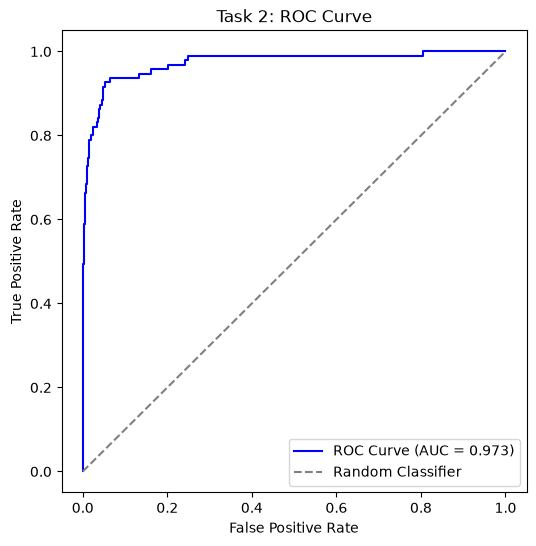

In [63]:
# Task 2: YOUR CODE HERE
import matplotlib.pyplot as plt
fpr, tpr, thresholds = roc_curve(y_test, y_proba)
print(tpr)
auc = roc_auc_score(y_test, y_proba)
fig, ax = plt.subplots(figsize=(6, 6))
ax.plot(fpr, tpr, color='blue', label=f'ROC Curve (AUC = {auc:.3f})')
ax.plot([0, 1], [0, 1], color='gray', linestyle='--', label='Random Classifier')
ax.set_title('Task 2: ROC Curve')
ax.set_xlabel('False Positive Rate')
ax.set_ylabel('True Positive Rate')
ax.legend()

### Task 3: Learning Curves -- Diagnose

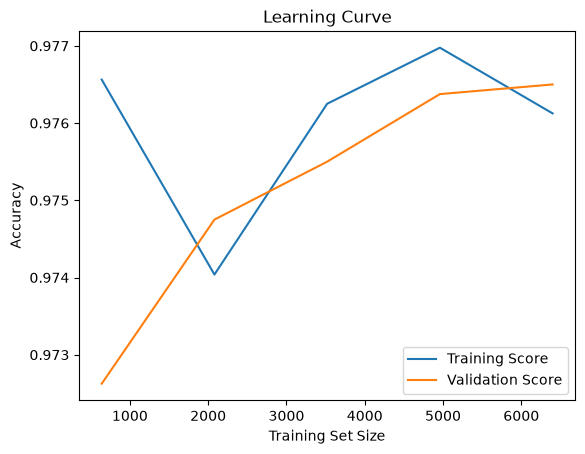

In [65]:
# Task 3: YOUR CODE HERE
# Plot Learning Curve


train_sizes, train_scores, val_scores = learning_curve(LogisticRegression(), X_train, y_train, cv=5)
plt.plot(train_sizes, np.mean(train_scores, axis=1), label='Training Score')
plt.plot(train_sizes, np.mean(val_scores, axis=1), label='Validation Score')
plt.xlabel('Training Set Size')
plt.ylabel('Accuracy')
plt.title('Learning Curve')
plt.legend()

### Task 4: Confidently Wrong Predictions

In [67]:
# Task 4: YOUR CODE HERE
# Confidently Wrong Predictions
misclassified_mask = y_pred != y_test.values
misclassified_samples = X_test[misclassified_mask].copy()
misclassified_samples['actual'] = y_test.values[misclassified_mask]
misclassified_samples['predicted'] = y_pred[misclassified_mask]
misclassified_samples['confidence'] = np.where(
    misclassified_samples['predicted'] == 1,
    y_proba[misclassified_mask],
    1 - y_proba[misclassified_mask]
)
misclassified_samples_sorted = misclassified_samples.sort_values(by='confidence', ascending=False)
print("\nTask 4: Top 5 Most Confidently Wrong Predictions")
print(misclassified_samples_sorted.head(5))


Task 4: Top 5 Most Confidently Wrong Predictions
      transaction_amount  distance_from_home  time_of_day  is_online  \
1440              150.27               20.82        23.57          0   
5898               88.39               25.54        20.24          1   
3714              121.98               42.48        19.66          1   
7633              284.11               24.47        20.90          1   
8616              216.45               27.08        23.89          1   

      merchant_risk_score  customer_age  transaction_frequency  actual  \
1440               0.2837          44.9                     11       1   
5898               0.2861          45.3                      5       1   
3714               0.2965          26.5                     10       1   
7633               0.2467          54.1                      8       1   
8616               0.2650          18.0                      8       1   

      predicted  confidence  
1440          0    0.999605  
5898        

### Task 5: Your Recommendation

**Your Fraud Model Recommendation:**

1. **Overall quality:** AUC = ___, F1 = ___ -- acceptable?
2. **Diagnosis:** Overfitting / Underfitting / Good fit -- evidence: ___
3. **Next step:** ___
4. **Business justification:** ___

---

## Summary & Key Takeaways

Today you built a complete **model diagnostic toolkit**:

1. **Multi-class confusion matrix** -- see WHERE errors happen across all classes
2. **Macro/weighted/micro averaging** -- fairly assess multi-class performance
3. **ROC-AUC** -- evaluate model quality independent of threshold choice
4. **Bias-variance tradeoff** -- understand WHY models fail
5. **Learning curves** -- diagnose overfitting vs underfitting
6. **5-step error analysis** -- systematically debug any model
7. **Cost-sensitive evaluation** -- choose metrics based on business impact

> <font color="#c62828"><b>The key lesson:</b></font> The right metric depends on the business problem. There is no universal "best metric." Always ask: **what does each type of error COST?**

### What's Next

**Session 10.1: Data Collection -- APIs & Web Scraping.** You can now build AND debug models. Next: where does the data come from?

---

Vishlesan i-Hub IIT Patna x Masai School